In [1]:
# Cell 1: Import Libraries and Set Configuration
"""
Experiment: Measure convergence rate to Gaussian for different graph topologies
Compare chain, tree, and grid graphs
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
sys.path.insert(0, '/home/tom/Projects/gbp_clt/src')
import config as cfg
import distribution_management as dm
import factor_graph as fg
import belief_propagation as bp
from belief_propagation import run_belief_propagation
import optimisation as opt

# Fixed parameters
cfg.belief_discretisation = 1024
cfg.num_iterations = 30
cfg.smoothing_width = 12
cfg.prior_width = 16
cfg.min_measurement = -32
cfg.max_measurement = 31
cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)

# Experiment parameters
num_seeds = 100 #100
max_hops = 6
tree_branching_factor = 2
seeds = np.arange(42, 42 + num_seeds)

In [2]:
# Cell 2: Helper Functions

def optimise_gaussian_kl(y_values, x_values):
    """Find Gaussian that minimizes KL divergence from target_belief"""
    bin_width = (x_values[-1] - x_values[0]) / len(x_values)
    sigma_min = 2*bin_width
    sigma_max = (x_values[-1] - x_values[0]) * 10.0
    num_sigma_steps = 100
    
    optimal_mean = x_values[np.argmax(y_values)]
    sigma_search_values = np.logspace(np.log10(sigma_min), np.log10(sigma_max), num_sigma_steps)
    min_kl = float('inf')
    optimal_sigma = None
        
    for sigma_candidate in sigma_search_values:
        y_gauss = opt.create_gaussian_distribution(x_values, sigma_candidate, mu=optimal_mean)
        current_kl = opt.kl_divergence_numba(y_values, y_gauss)

        if np.isnan(current_kl):
            continue

        if current_kl < min_kl:
            min_kl = current_kl
            optimal_sigma = sigma_candidate

    return min_kl, optimal_sigma, optimal_mean

def build_chain_graph(num_variables, prior_factor=None):
    """Build a chain graph with prior at one end"""
    graph = fg.FactorGraph()
    graph.add_variables(num_variables, cfg.belief_discretisation)
    
    # Add smoothing factors between consecutive variables
    smoothing_kernel = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.smoothing_width)
    smoothing_function = dm.create_smoothing_factor_distribution(
        cfg.belief_discretisation, 
        kernel=smoothing_kernel
    )
    
    for i in range(num_variables - 1):
        graph.add_factor(
            [graph.variables[i], graph.variables[i + 1]], 
            function=smoothing_function
        )
    
    # Add prior to first variable
    if prior_factor is None:
        prior_factor = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.prior_width)
    
    graph.add_factor([graph.variables[0]], prior_factor, factor_type='prior')
    
    return graph

def build_tree_graph(num_layers, branching_factor, prior_factor=None):
    """Build a tree graph with priors at leaf nodes"""
    graph = fg.FactorGraph()
    
    # Calculate total number of nodes
    total_nodes = (branching_factor**num_layers - 1) // (branching_factor - 1)
    graph.add_variables(total_nodes, cfg.belief_discretisation)
    
    # Create smoothing function
    smoothing_kernel = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.smoothing_width)
    smoothing_function = dm.create_smoothing_factor_distribution(
        cfg.belief_discretisation, 
        kernel=smoothing_kernel
    )
    
    # Build tree structure (breadth-first)
    node_idx = 0
    for layer in range(num_layers - 1):
        layer_start = (branching_factor**layer - 1) // (branching_factor - 1)
        layer_size = branching_factor**layer
        
        for i in range(layer_size):
            parent_idx = layer_start + i
            for j in range(branching_factor):
                child_idx = layer_start + layer_size + i * branching_factor + j
                graph.add_factor(
                    [graph.variables[parent_idx], graph.variables[child_idx]],
                    function=smoothing_function
                )
    
    # Add priors to leaf nodes
    leaf_start = (branching_factor**(num_layers-1) - 1) // (branching_factor - 1)
    num_leaves = branching_factor**(num_layers-1)

    if prior_factor is None:
        prior_factor = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.prior_width)
    
    for i in range(num_leaves):
        leaf_idx = leaf_start + i
        graph.add_factor([graph.variables[leaf_idx]], prior_factor, factor_type='prior')
    
    return graph

def build_grid_graph(rows, cols, prior_corner='top_left', prior_factor=None):
    """Build a grid graph with prior at one corner"""
    graph = fg.FactorGraph()
    num_variables = rows * cols
    graph.add_variables(num_variables, cfg.belief_discretisation)
    
    # Create smoothing function
    smoothing_kernel = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.smoothing_width)
    smoothing_function = dm.create_smoothing_factor_distribution(
        cfg.belief_discretisation, 
        kernel=smoothing_kernel
    )
    
    # Add horizontal edges
    for row in range(rows):
        for col in range(cols - 1):
            idx1 = row * cols + col
            idx2 = row * cols + col + 1
            graph.add_factor(
                [graph.variables[idx1], graph.variables[idx2]],
                function=smoothing_function
            )
    
    # Add vertical edges
    for row in range(rows - 1):
        for col in range(cols):
            idx1 = row * cols + col
            idx2 = (row + 1) * cols + col
            graph.add_factor(
                [graph.variables[idx1], graph.variables[idx2]],
                function=smoothing_function
            )
    
    # Add prior to corner
    if prior_corner == 'top_left':
        prior_idx = 0
    elif prior_corner == 'top_right':
        prior_idx = cols - 1
    elif prior_corner == 'bottom_left':
        prior_idx = (rows - 1) * cols
    else:  # bottom_right
        prior_idx = rows * cols - 1
    
    if prior_factor is None:
        prior_factor = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.prior_width)
    graph.add_factor([graph.variables[prior_idx]], prior_factor, factor_type='prior')
    
    return graph, prior_idx

def get_chain_distances(num_variables):
    """Get distances along chain from first variable"""
    return list(range(num_variables))

def get_tree_branch_distances(num_layers, branching_factor):
    """Get distances along one branch from leaf to root"""
    # Follow the first branch from leaf to root
    distances = []
    indices = []
    
    # Start at first leaf
    leaf_start = (branching_factor**(num_layers-1) - 1) // (branching_factor - 1)
    current_idx = leaf_start
    indices.append(current_idx)
    
    # Traverse up to root
    for layer in range(num_layers - 1, 0, -1):
        # Find parent
        layer_start = (branching_factor**layer - 1) // (branching_factor - 1)
        position_in_layer = current_idx - layer_start
        parent_layer_start = (branching_factor**(layer-1) - 1) // (branching_factor - 1)
        parent_idx = parent_layer_start + position_in_layer // branching_factor
        indices.append(parent_idx)
        current_idx = parent_idx
    
    # Distances are reversed (0 at leaf, increasing towards root)
    distances = list(range(num_layers))
    
    return indices, distances

def get_grid_distances_manhattan(rows, cols, prior_idx):
    """Get Manhattan distances from prior corner in grid"""
    prior_row = prior_idx // cols
    prior_col = prior_idx % cols
    
    distances_dict = {}
    for row in range(rows):
        for col in range(cols):
            idx = row * cols + col
            distance = abs(row - prior_row) + abs(col - prior_col)
            distances_dict[idx] = distance
    
    return distances_dict

In [3]:
# Cell 3: Run Experiments (using synthetic_data_app approach)

print("Running convergence rate experiments...")
print(f"Using {num_seeds} random seeds\n")

# Storage for results
chain_results = defaultdict(list)  # distance -> [kl_values across seeds]
tree_results = defaultdict(list)
grid_results = defaultdict(list)

for seed_idx, seed in enumerate(seeds):
    print(f"Running seed {seed} ({seed_idx+1}/{num_seeds})...")
    
    # Set random seed
    cfg.random_seed = seed
    cfg.rng = np.random.default_rng(seed=seed)
    np.random.seed(seed)
    
    # Update config for this experiment
    cfg.num_variables = max_hops + 1
    cfg.num_priors = 1
    cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)
    
    common_prior_distribution = dm.create_random_prior_distribution(
        cfg.measurement_range,
        prior_width=cfg.prior_width
    )
    
    # 1. CHAIN GRAPH - treat as tree with branching_factor=1
    print("  Building chain graph...")
    cfg.graph_type = 'Tree'
    cfg.prior_location = 'leaf'
    cfg.branching_factor = 1
    cfg.branching_probability = 1.0
    cfg.num_variables = 2*max_hops + 1
    cfg.num_priors = 1
    
    chain_graph = fg.build_factor_graph(
        cfg.num_variables,
        cfg.num_priors,
        cfg.num_loops,
        cfg.graph_type,
        cfg.measurement_range,
        cfg.prior_location,
        cfg.branching_factor,
        cfg.branching_probability,
        prior_distribution=common_prior_distribution
    )
    chain_graph = bp.run_belief_propagation(chain_graph, cfg.num_iterations)
    
    # Get distances and compute KL divergences
    length_to_priors = opt.find_all_nearest_priors(chain_graph)
    for var_idx, variable in enumerate(chain_graph.variables):
        distance = length_to_priors[variable.name]
        kl_div, _, _ = optimise_gaussian_kl(variable.belief, cfg.measurement_range)
        chain_results[distance].append(kl_div)
    

    # 2. TREE GRAPH with branching factor 2
    print("  Building tree graph...")
    cfg.branching_factor = 2
    cfg.num_variables = (cfg.branching_factor**(max_hops + 1) - 1) // (cfg.branching_factor - 1)

    tree_graph = fg.build_factor_graph(
        cfg.num_variables,
        cfg.num_priors,
        cfg.num_loops,
        cfg.graph_type,
        cfg.measurement_range,
        cfg.prior_location,
        cfg.branching_factor,
        cfg.branching_probability,
        prior_distribution=common_prior_distribution
    )
    # print("num tree priors:", len([f for f in tree_graph.factors if f.factor_type == 'prior']))
    tree_graph = bp.run_belief_propagation(tree_graph, cfg.num_iterations)
    
    # Get distances and compute KL divergences
    length_to_priors = opt.find_all_nearest_priors(tree_graph)
    for variable in tree_graph.variables:
        distance = length_to_priors[variable.name]
        if distance <= max_hops:  # Only keep distances up to max_hops
            kl_div, _, _ = optimise_gaussian_kl(variable.belief, cfg.measurement_range)
            tree_results[distance].append(kl_div)
    
    # 3. GRID GRAPH (6x6)
    print("  Building grid graph...")
    cfg.graph_type = 'Grid'
    cfg.num_variables = (max_hops//2 + 1)**2  # 6x6 grid
    cfg.prior_location = 'corners'
    cfg.num_priors = 1
    
    grid_graph = fg.build_factor_graph(
        cfg.num_variables,
        cfg.num_priors,
        cfg.num_loops,
        cfg.graph_type,
        cfg.measurement_range,
        cfg.prior_location,
        cfg.branching_factor,
        cfg.branching_probability,
        prior_distribution=common_prior_distribution
    )
    grid_graph = bp.run_belief_propagation(grid_graph, cfg.num_iterations)
    
    # Get distances and compute KL divergences
    length_to_priors = opt.find_all_nearest_priors(grid_graph)
    for variable in grid_graph.variables:
        distance = length_to_priors[variable.name]
        if distance <= max_hops:  # Only keep distances up to max_hops
            kl_div, _, _ = optimise_gaussian_kl(variable.belief, cfg.measurement_range)
            grid_results[distance].append(kl_div)
    
    print(f"  Seed {seed} complete\n")

print("All experiments complete!")

Running convergence rate experiments...
Using 100 random seeds

Running seed 42 (1/100)...
  Building chain graph...
Building factor graph...
Adding variables to graph...
Adding prior factors to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Building tree graph...
Building factor graph...
Adding variables to graph...
Adding prior factors to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Building grid graph...
Building factor graph...
Adding variables to graph...
Calculating pairwise grid connections...
Creating pairwise factors...
All pairwise factors added.
Adding prior factors to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  Seed 42 co

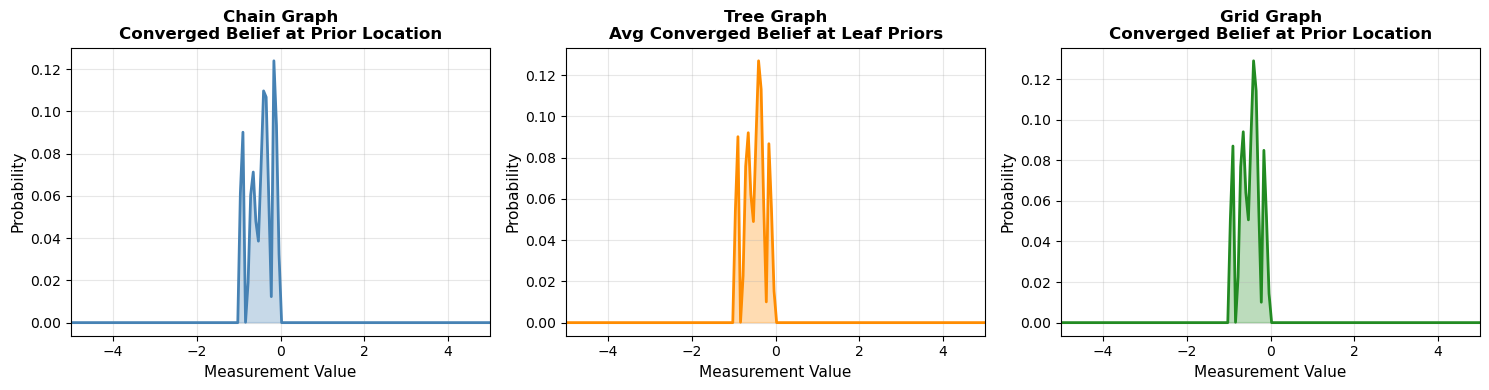

In [4]:
# # Cell 3.5: Visualize Prior Distributions

# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# # 1. Chain graph prior
# chain_prior_factors = [f for f in chain_graph.factors if f.factor_type == 'prior']
# if chain_prior_factors:
#     chain_prior = chain_prior_factors[0]
#     axes[0].plot(cfg.measurement_range, chain_prior.function, linewidth=2, color='steelblue')
#     axes[0].fill_between(cfg.measurement_range, chain_prior.function, alpha=0.3, color='steelblue')
#     axes[0].set_title('Chain Graph\nPrior Distribution', fontsize=12, fontweight='bold')
#     axes[0].set_xlabel('Measurement Value', fontsize=11)
#     axes[0].set_ylabel('Probability', fontsize=11)
#     axes[0].grid(True, alpha=0.3)

# # 2. Tree graph prior
# tree_prior_factors = [f for f in tree_graph.factors if f.factor_type == 'prior']
# if tree_prior_factors:
#     tree_prior = tree_prior_factors[0]
#     axes[1].plot(cfg.measurement_range, tree_prior.function, linewidth=2, color='darkorange')
#     axes[1].fill_between(cfg.measurement_range, tree_prior.function, alpha=0.3, color='darkorange')
#     axes[1].set_title('Tree Graph\nPrior Distribution', fontsize=12, fontweight='bold')
#     axes[1].set_xlabel('Measurement Value', fontsize=11)
#     axes[1].set_ylabel('Probability', fontsize=11)
#     axes[1].grid(True, alpha=0.3)

# # 3. Grid graph prior
# grid_prior_factors = [f for f in grid_graph.factors if f.factor_type == 'prior']
# if grid_prior_factors:
#     grid_prior = grid_prior_factors[0]
#     axes[2].plot(cfg.measurement_range, grid_prior.function, linewidth=2, color='forestgreen')
#     axes[2].fill_between(cfg.measurement_range, grid_prior.function, alpha=0.3, color='forestgreen')
#     axes[2].set_title('Grid Graph\nPrior Distribution', fontsize=12, fontweight='bold')
#     axes[2].set_xlabel('Measurement Value', fontsize=11)
#     axes[2].set_ylabel('Probability', fontsize=11)
#     axes[2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('prior_distributions_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
# plt.show()


# Cell 3.6: Visualize Converged Beliefs at Prior Locations

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Chain graph - belief of variable with prior (first variable)
chain_prior_var = chain_graph.variables[0]
axes[0].plot(cfg.measurement_range, chain_prior_var.belief, linewidth=2, color='steelblue')
axes[0].fill_between(cfg.measurement_range, chain_prior_var.belief, alpha=0.3, color='steelblue')
axes[0].set_title('Chain Graph\nConverged Belief at Prior Location', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Measurement Value', fontsize=11)
axes[0].set_xlim(left=-5, right=5)
axes[0].set_ylabel('Probability', fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Tree graph - average belief of all leaf variables
tree_prior_factors = [f for f in tree_graph.factors if f.factor_type == 'prior']
tree_leaf_beliefs = []
for prior_factor in tree_prior_factors:
    leaf_var = prior_factor.neighbors[0]
    tree_leaf_beliefs.append(leaf_var.belief)

avg_tree_leaf_belief = np.mean(tree_leaf_beliefs, axis=0)
axes[1].plot(cfg.measurement_range, avg_tree_leaf_belief, linewidth=2, color='darkorange')
axes[1].fill_between(cfg.measurement_range, avg_tree_leaf_belief, alpha=0.3, color='darkorange')
axes[1].set_title('Tree Graph\nAvg Converged Belief at Leaf Priors', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Measurement Value', fontsize=11)
axes[1].set_xlim(left=-5, right=5)
axes[1].set_ylabel('Probability', fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. Grid graph - belief of variable with prior
grid_prior_factors = [f for f in grid_graph.factors if f.factor_type == 'prior']
if grid_prior_factors:
    grid_prior_var = grid_prior_factors[0].neighbors[0]
    axes[2].plot(cfg.measurement_range, grid_prior_var.belief, linewidth=2, color='forestgreen')
    axes[2].fill_between(cfg.measurement_range, grid_prior_var.belief, alpha=0.3, color='forestgreen')
    axes[2].set_title('Grid Graph\nConverged Belief at Prior Location', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Measurement Value', fontsize=11)
    axes[2].set_xlim(left=-5, right=5)
    axes[2].set_ylabel('Probability', fontsize=11)
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('converged_beliefs_at_priors.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Cell 4: Compute Statistics

# Compute mean and std for each topology
def compute_stats(results_dict):
    distances = sorted(results_dict.keys())
    means = []
    stds = []
    
    for dist in distances:
        kl_values = results_dict[dist]
        means.append(np.mean(kl_values))
        stds.append(np.std(kl_values))
    
    return distances, np.array(means), np.array(stds)

chain_distances, chain_means, chain_stds = compute_stats(chain_results)
tree_distances, tree_means, tree_stds = compute_stats(tree_results)
grid_distances, grid_means, grid_stds = compute_stats(grid_results)

print("Chain statistics:")
print(f"  Distances: {chain_distances}")
print(f"  Mean KL: {chain_means}")
print(f"  Std KL: {chain_stds}\n")

print("Tree statistics:")
print(f"  Distances: {tree_distances}")
print(f"  Mean KL: {tree_means}")
print(f"  Std KL: {tree_stds}\n")

print("Grid statistics:")
print(f"  Distances: {grid_distances}")
print(f"  Mean KL: {grid_means}")
print(f"  Std KL: {grid_stds}")

Chain statistics:
  Distances: [0, 1, 2, 3, 4, 5, 6]
  Mean KL: [0.61814266 0.07149685 0.01891676 0.00509604 0.0024221  0.00177038
 0.00193882]
  Std KL: [0.24180114 0.04709966 0.01797664 0.00372126 0.00181456 0.00113286
 0.00116697]

Tree statistics:
  Distances: [0, 1, 2, 3, 4, 5, 6]
  Mean KL: [0.37133163 0.0753322  0.02585505 0.0089001  0.00659427 0.00596732
 0.00593357]
  Std KL: [0.16072772 0.06306283 0.02999156 0.01101099 0.005746   0.00478362
 0.00576943]

Grid statistics:
  Distances: [0, 1, 2, 3, 4, 5, 6]
  Mean KL: [0.34798329 0.00328843 0.00381077 0.00372953 0.00302335 0.00259316
 0.00302872]
  Std KL: [0.14068578 0.00283257 0.00207474 0.00185844 0.00193841 0.0016364
 0.00115693]


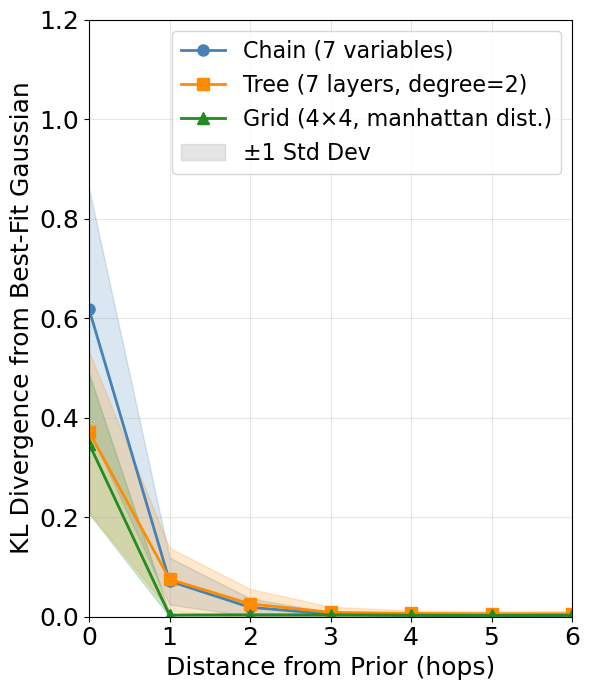

In [8]:
# Cell 5: Plot Results

FIG_SIZE = (6, 7)
AXIS_FONT = 18
TICK_FONT = 18
LEGEND_FONT = 16

fig, ax = plt.subplots(1, 1, figsize=FIG_SIZE)

# Plot chain
ax.plot(chain_distances, chain_means, 'o-', linewidth=2, markersize=8, 
        label=f'Chain ({max_hops+1} variables)', color='steelblue')
ax.fill_between(chain_distances, chain_means - chain_stds, chain_means + chain_stds, 
                alpha=0.2, color='steelblue')

# Plot tree
ax.plot(tree_distances, tree_means, 's-', linewidth=2, markersize=8, 
        label=f'Tree ({max_hops+1} layers, degree={tree_branching_factor})', color='darkorange')
ax.fill_between(tree_distances, tree_means - tree_stds, tree_means + tree_stds, 
                alpha=0.2, color='darkorange')

# Plot grid
ax.plot(grid_distances, grid_means, '^-', linewidth=2, markersize=8, 
        label=f'Grid ({max_hops//2 + 1}×{max_hops//2 + 1}, manhattan dist.)', color='forestgreen')
ax.fill_between(grid_distances, grid_means - grid_stds, grid_means + grid_stds, 
                alpha=0.2, color='forestgreen')

# Add a dummy patch for the shaded region legend
from matplotlib.patches import Patch
shaded_patch = Patch(alpha=0.2, color='gray', label='±1 Std Dev')

ax.set_xlabel('Distance from Prior (hops)', fontsize=AXIS_FONT)
ax.set_ylabel('KL Divergence from Best-Fit Gaussian', fontsize=AXIS_FONT)
# ax.set_title('Convergence Rate to Gaussian: Topology Comparison', fontsize=15, fontweight='bold')
ax.set_ylim(bottom=0, top=1.2)
ax.set_xlim(left=0, right=max_hops)

ax.legend(handles=ax.get_legend_handles_labels()[0] + [shaded_patch], fontsize=LEGEND_FONT, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='both', labelsize=TICK_FONT)

plt.tight_layout()
plt.savefig('convergence_rate_topology_comparison.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()